# 01 — Quickstart: Opening an IWFM Model

**iwfm-io** is a Python toolkit for the [Integrated Water Flow Model
(IWFM)](https://water.ca.gov/Library/Modeling-and-Analysis/Modeling-Platforms/Integrated-Water-Flow-Model),
DWR's integrated groundwater–surface water model. It has three parts:

| Part | Import | Needs |
|------|--------|-------|
| Pure-Python file I/O (readers/writers for every input & output file) | `iwfm_io` | nothing — cross-platform |
| Plotting library (58 matplotlib functions) | `iwfm_io.plots` | matplotlib |
| DLL wrapper (live model queries) | `iwfm_io.dll` | Windows x64 + IWFM DLL |

```
pip install iwfm-io            # core (pandas, numpy, h5py, matplotlib)
pip install iwfm-io[geo]       # + geopandas/shapely GeoDataFrames
pip install iwfm-io[dss]       # + HEC-DSS reading (CalSim integration)
pip install iwfm-io[pest]      # + pyemu for PEST++ binary ensembles
```

This notebook is the 5-minute tour: open a model, orient yourself with
`describe()`, and pull grid, head, and budget DataFrames.

**Requires:** the IWFM sample model (441 nodes, 400 elements, 2 layers,
a 10-year daily simulation). If you cloned the repo it lives in
`.assets/sample_model/`; otherwise download `sample_model.zip` from the
[GitHub release assets](https://github.com/SercanC/iwfm-io/releases),
extract it, and point `IWFM_SAMPLE_MODEL` at the folder.

In [1]:
import os
from pathlib import Path


def find_sample_model():
    env = os.environ.get("IWFM_SAMPLE_MODEL")
    if env:
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / ".assets" / "sample_model"
        if cand.is_dir():
            return cand
    raise FileNotFoundError(
        "Sample model not found — download sample_model.zip from "
        "https://github.com/SercanC/iwfm-io/releases, extract it, and "
        "set the IWFM_SAMPLE_MODEL environment variable to its path."
    )


SAMPLE_MODEL = find_sample_model()
SAMPLE_MODEL

WindowsPath('C:/Projects/iwfm-io/.assets/sample_model')

## Open the model

`open_model()` is the recommended entry point. Point it at the model's
**root folder** — it discovers the preprocessor/simulation main files and
any Results HDF files, and returns an `IOModelAdapter` that serves
everything as pandas DataFrames. No DLL, no Fortran, works on any OS.

In [2]:
from iwfm_io import open_model

model = open_model(SAMPLE_MODEL)
model

<IOModelAdapter: 441 nodes, 400 elements, 2 layers, 11 budgets, heads>

## Orient yourself: `describe()`

`describe()` returns a JSON-serializable summary — grid size, simulation
period, and every budget/hydrograph output that was discovered, with its
location names. It is the source of truth for the names you pass to
`budget_df()` and friends.

In [3]:
import json

desc = model.describe()
print(json.dumps({k: v for k, v in desc.items() if k != "results"}, indent=2))

{
  "source": "iwfm_io file readers (no DLL)",
  "model_root": "C:\\Projects\\iwfm-io\\.assets\\sample_model",
  "grid": {
    "n_nodes": 441,
    "n_elements": 400,
    "n_layers": 2,
    "n_subregions": 2,
    "subregion_names": {
      "1": "Region1",
      "2": "Region2"
    }
  },
  "streams": {
    "n_reaches": 3,
    "n_stream_nodes": 23
  },
  "lakes": {
    "n_lakes": 1
  },
  "simulation": {
    "begins": "09/30/1990_24:00",
    "ends": "09/30/2000_24:00",
    "timestep": "1DAY"
  }
}


In [4]:
# Available budget outputs and their locations
for name, info in desc["results"]["budgets"].items():
    print(f"{name:14s} {info['locations']}")

DiverDetail    ['DIVERSION_1(SN9)', 'DIVERSION_2(SN12)', 'DIVERSION_3(SN12)', 'DIVERSION_4(SN22)', 'DIVERSION_5(SN0)']
GW             ['ENTIRE MODEL AREA', 'Region1 (SR1)', 'Region2 (SR2)']
LakeBud        ['Lake1']
LWU            ['ENTIRE MODEL AREA', 'Region1 (SR1)', 'Region2 (SR2)']
LWU_TO         ['ENTIRE MODEL AREA_TO', 'Region1 (SR1)_TO', 'Region2 (SR2)_TO']
RootZone       ['ENTIRE MODEL AREA', 'Region1 (SR1)', 'Region2 (SR2)']
RZBud_TO       ['ENTIRE MODEL AREA_TO', 'Region1 (SR1)_TO', 'Region2 (SR2)_TO']
StrmBud        ['Reach1(REACH 1)', 'Reach2(REACH 2)', 'Reach3(REACH 3)']
StrmNodeBud    ['NODE 1', 'NODE 19', 'NODE 8']
SWShed         ['WATERSHED 1', 'WATERSHED 2', 'WATERSHED 3']
UnsatZoneBud   ['ENTIRE MODEL AREA', 'Region1 (SR1)', 'Region2 (SR2)']


## The grid as DataFrames

`nodes_df()` returns a GeoDataFrame when geopandas is installed
(`pip install iwfm-io[geo]`), a plain DataFrame otherwise. Elements carry
their four node ids (`node4 == 0` means a triangle) and subregion.

In [5]:
nodes = model.nodes_df()
print(f"{model.n_nodes} nodes, {model.n_elements} elements, "
      f"{model.n_layers} layers, {model.n_subregions} subregions")
nodes.head()

441 nodes, 400 elements, 2 layers, 2 subregions


,node_id,x,y,geometry
0,1,550000.0,4400000.0,POINT (550000 4400000)
1,2,552000.0,4400000.0,POINT (552000 4400000)
2,3,554000.0,4400000.0,POINT (554000 4400000)
3,4,556000.0,4400000.0,POINT (556000 4400000)
4,5,558000.0,4400000.0,POINT (558000 4400000)


In [6]:
model.elements_df().head()

,element_id,node1,node2,node3,node4,subregion,geometry
0,1,1,2,23,22,1,"POLYGON ((550000 4400000, 552000 4400000, 5520..."
1,2,2,3,24,23,1,"POLYGON ((552000 4400000, 554000 4400000, 5540..."
2,3,3,4,25,24,1,"POLYGON ((554000 4400000, 556000 4400000, 5560..."
3,4,4,5,26,25,1,"POLYGON ((556000 4400000, 558000 4400000, 5580..."
4,5,5,6,27,26,1,"POLYGON ((558000 4400000, 560000 4400000, 5600..."


In [7]:
# Stratigraphy: ground-surface elevation + per-layer aquitard/aquifer thickness
model.stratigraphy_df().head()

,node_id,elevation,aquitard_1,aquifer_1,aquitard_2,aquifer_2
0,1,500.0,0.0,500.0,10.0,100.0
1,2,500.0,0.0,500.0,10.0,100.0
2,3,500.0,0.0,500.0,10.0,100.0
3,4,500.0,0.0,500.0,10.0,100.0
4,5,500.0,0.0,500.0,10.0,100.0


## Groundwater heads

`heads_df(layer=...)` reads the all-node head output (HDF when present,
text `GWHeadAll.out` as fallback): one row per timestep, one column per
node.

In [8]:
heads = model.heads_df(layer=1)
print(f"heads: {heads.shape[0]} timesteps x {heads.shape[1]} nodes, "
      f"{heads.index[0].date()} - {heads.index[-1].date()}")
heads.iloc[:3, :5]

heads: 3654 timesteps x 441 nodes, 1990-10-01 - 2000-10-01


,node_1,node_2,node_3,node_4,node_5
datetime,,,,,
1990-10-01,290.0,280.0000,280.0000,280.0000,280.0000
1990-10-02,290.0,280.0403,280.0229,280.0229,280.0229
1990-10-03,290.0,280.0585,280.0237,280.0235,280.0235


In [9]:
# Depth to water at the end of the simulation
strat = model.stratigraphy_df()
dtw = strat["elevation"].to_numpy() - heads.iloc[-1].to_numpy()
print(f"end-of-run depth to water (ft): min={dtw.min():.1f} "
      f"max={dtw.max():.1f} mean={dtw.mean():.1f}")

end-of-run depth to water (ft): min=-35.0 max=362.4 mean=150.4


## Budgets

`budget_df(budget, location)` returns one column per budget component
with a `DatetimeIndex`. `location` is a 1-based index or an exact
location name from `describe()`.

In [10]:
gw_bud = model.budget_df("GW", location="ENTIRE MODEL AREA")
gw_bud.head(3)

,Percolation,Beginning Storage (+),Ending Storage (-),Deep Percolation (+),Gain from Stream (+),Recharge (+),Gain from Lake (+),Boundary Inflow (+),Subsidence (+),Subsurface Irrigation (+),Tile Drain Outflow (-),Pumping (-),GW Return Flow (-),Outflow to Root Zone (-),Net Subsurface Inflow (+),Discrepancy (=),Cumulative Subsidence
datetime,,,,,,,,,,,,,,,,,
1990-10-02,1.414547e+07,1.640838e+12,1.640645e+12,0.0,-2.853643e+08,0.0,1.563706e+06,1.656614e+07,7.501907e+07,0.0,9012.502298,562064.516129,0.0,0.0,0.0,-3.706011,7.501907e+07
1990-10-03,1.415094e+07,1.640645e+12,1.640529e+12,0.0,-1.417441e+08,0.0,4.333493e+06,1.565458e+07,6.556101e+06,0.0,9736.568583,562064.516129,0.0,0.0,0.0,-0.921898,8.157517e+07
1990-10-04,1.415715e+07,1.640529e+12,1.640494e+12,0.0,-5.578854e+07,0.0,4.912072e+06,1.563629e+07,1.122334e+06,0.0,9813.609715,562064.516129,0.0,0.0,0.0,11.573208,8.269750e+07


In [11]:
# Water-year aggregation the right way: aggregate_budget knows the
# component semantics — flow components sum over the year, while the
# storage *stocks* take the period's first/last value — and it honors
# the 24:00 convention, so a 9/30 stamp lands in the water year it
# closes. (Values are model-internal volumes. For raw pandas idioms,
# budget_df/heads_df also take day_index=True — see notebook 03.)
from iwfm_io import aggregate_budget

annual = aggregate_budget(gw_bud, period="WY")
annual[["Beginning Storage (+)", "Ending Storage (-)",
        "Deep Percolation (+)", "Pumping (-)"]].head()

,Beginning Storage (+),Ending Storage (-),Deep Percolation (+),Pumping (-)
water_year,,,,
1991,1.640838e+12,1.641221e+12,1.571540e+08,1.118820e+10
1992,1.641221e+12,1.643021e+12,1.068485e+09,1.117217e+10
1993,1.643021e+12,1.645383e+12,2.461421e+09,1.115623e+10
1994,1.645383e+12,1.650082e+12,6.036406e+09,1.114605e+10
1995,1.650082e+12,1.672327e+12,2.640340e+10,1.113929e+10


## A first look at the model — two quick maps

The plotting library takes the adapter directly. Every function returns
`(fig, ax)` and accepts `save_path=`.

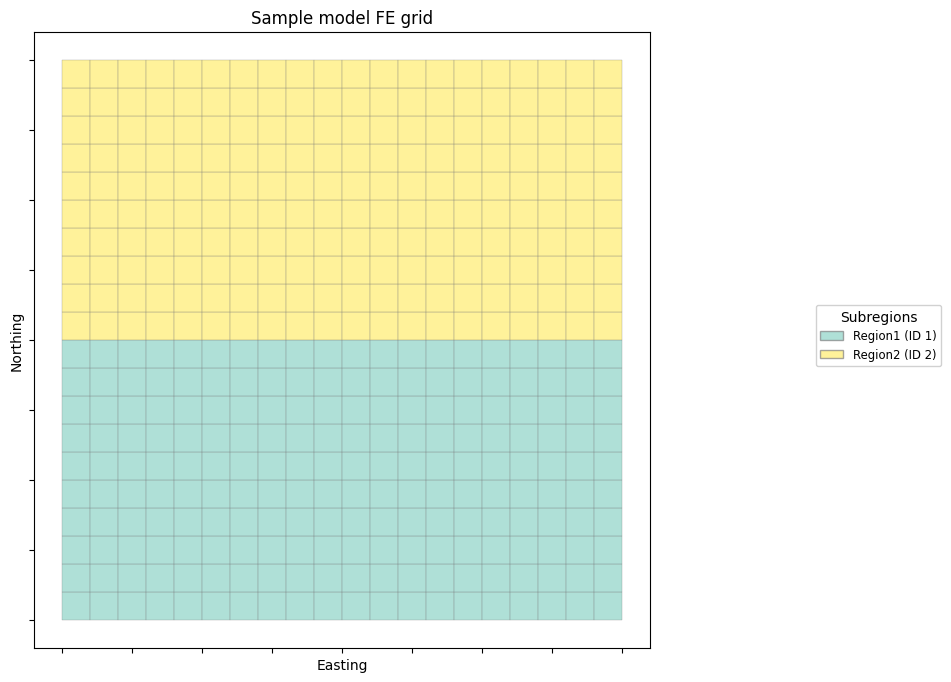

In [12]:
import matplotlib.pyplot as plt
from iwfm_io.plots import maps

fig, ax = maps.plot_grid_mesh(model, title="Sample model FE grid")
plt.show()

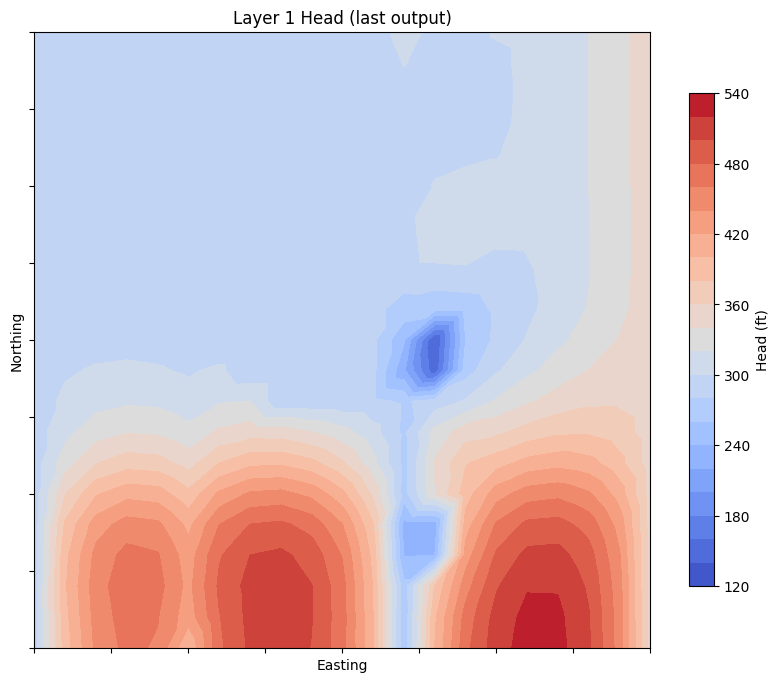

In [13]:
fig, ax = maps.plot_gw_head_contour(model, layer=1, time_index=-1)
plt.show()

## Where to go next

| Notebook | Topic |
|----------|-------|
| 02 | Reading every input file into DataFrames |
| 03 | Reading outputs: HDF budgets, heads, hydrographs, zone budgets |
| 04 | Writing files back — the read → edit → write round-trip |
| 05 | The DLL wrapper (Windows) |
| 06 | Scenarios and running the IWFM executables |
| 07 | Plotting gallery |
| 08 | Wells, gauges & observation metadata |
| 09 | PEST with IWFM part 1 — building a calibration |
| 10 | PEST with IWFM part 2 — analyzing IES results |
| 11 | CalSim / HEC-DSS integration |
| 12 | GIS & VTK exports — GeoPackage, shapefiles, 3D ParaView mesh |